# 05 Test Environment add curvature add length - Two Hills

In this notebook I will build upon the simulated annealing around the hill to add penalties for curvature and then also length. Currently the problem is a

$$
J_{\text{min}}(\gamma) = \int_\gamma c(x,y) \, ds
$$

Where $c$ is the cost field we are minimising over. With the added curvature term $\kappa$ and the length $L$ we get 

$$
J_{\text{min}}(\gamma) = \int_\gamma c(x,y) \, ds + \lambda \int_\gamma \kappa^2 \, ds + \alpha L
$$

$\lambda$ and $\alpha$ become constants to investigate for a realistic simulation.

Recall $\gamma$ is a paramiseation of the cruve that satifies the boundarys with $\gamma : [0,1] \rightarrow \mathbb{R}^2$. $\gamma \in \Gamma$ where $\Gamma$ is the set of admissable curves. 

we should also remember that $s$ is the arclength of the curve, so for a curve
$$
\gamma(t) = (x(t),y(t))
$$
The length is 
$$
L = \int_0^1 \|\gamma'(t)\| \,dt
$$
and the arc length is 
$$
s(t) = \int_0^t \|\gamma'(\tau)\| \,d\tau
$$
Building on this we note that the curvesture term $\kappa$ is
$$
\kappa(s) = \|\gamma''(s)\|
$$

This turns the problem into a 2nd order variational calculus problem since the curvature is dictated by $\gamma''$

In [73]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("../src")
from terrain.terrain import Terrain
from geometry.endpoints import Endpoints
from geometry.path import Path
from geometry.generators import straight_line_path


### terrain ### 
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)

terrain.add_hill(
    centre=(50, 50),
    peak_cost=50,
    radius=30

)


### boundarys ###

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()


terrain.grid.shape
terrain_df = terrain.to_dataframe()

### Initial Path
initial_path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

initial_path_df = initial_path.to_dataframe()

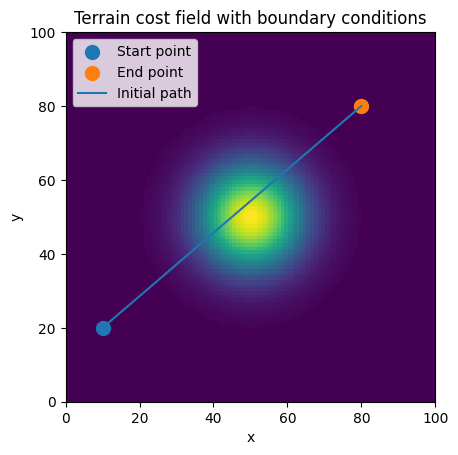

In [74]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    initial_path_df["x"],
    initial_path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [75]:
from cost_functions.terrain_cost import terrain_cost, terrain_curvature_cost, terrain_length_cost




print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))


1193.8650652339363
1.555318160733747e-26
92.19544457292892


In [76]:

from optimisation.moves import shift_move, segment_shift_move

new_path = segment_shift_move(
            initial_path,
            terrain,
            sigma=2,
            alpha=10,
            segment_length=5
        )

print(

    terrain_length_cost(initial_path),

    terrain_length_cost(new_path)

)

print(

    np.array_equal(

        initial_path.points,

        new_path.points

    )

)

92.19544457292892 92.19544457292892
True


In [77]:
from optimisation.annealing import simulated_segment_annealing_curvature


best_path_segment, best_cost_segment, history_segment, path_history_segment = simulated_segment_annealing_curvature(
    initial_path=initial_path,
    terrain=terrain,
    iterations=100000,
    initial_temperature=500,
    cooling_rate=0.999,
    sigma=0.3,
    alpha=10,
    terrain_weight=2,
    lam=20,
    mu=1
)


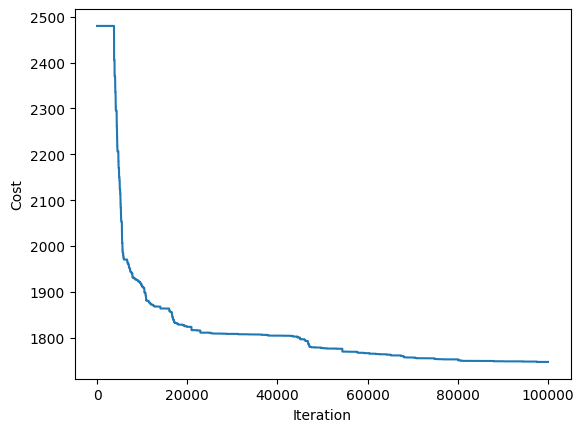

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

history_segment_df = pd.DataFrame(history_segment)

plt.plot(
    history_segment_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [79]:

best_path_segment_df = best_path_segment.to_dataframe()


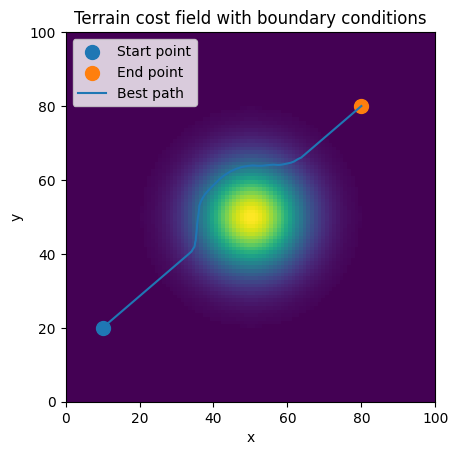

In [80]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_segment_df["x"],
    best_path_segment_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [81]:
print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))

print(terrain_cost(best_path_segment, terrain))
print(terrain_curvature_cost(best_path_segment))
print(terrain_length_cost(best_path_segment))

1193.8650652339363
1.555318160733747e-26
92.19544457292892
808.0033030629127
1.6507403536292304
98.42501492620015


In [82]:
print(best_path_segment_df.to_string(index=False))

 point         x         y
     0 10.000000 20.000000
     1 10.707071 20.606061
     2 11.414141 21.212121
     3 12.121212 21.818182
     4 12.828283 22.424242
     5 13.535354 23.030303
     6 14.242424 23.636364
     7 14.949495 24.242424
     8 15.656566 24.848485
     9 16.363636 25.454545
    10 17.070707 26.060606
    11 17.777778 26.666667
    12 18.484848 27.272727
    13 19.191919 27.878788
    14 19.898990 28.484848
    15 20.606061 29.090909
    16 21.313131 29.696970
    17 22.020202 30.303030
    18 22.727273 30.909091
    19 23.434343 31.515152
    20 24.141414 32.121212
    21 24.848485 32.727273
    22 25.555556 33.333333
    23 26.262626 33.939394
    24 26.969697 34.545455
    25 27.676768 35.151515
    26 28.383838 35.757576
    27 29.090909 36.363636
    28 29.797980 36.969697
    29 30.505051 37.575758
    30 31.212121 38.181818
    31 31.919192 38.787879
    32 32.626263 39.393939
    33 33.333333 40.000000
    34 34.095527 40.699698
    35 34.432536 41.319590
 

In [83]:
print(len(path_history_segment))

13647


Animation for posting and showing Yasemin

In [84]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Reduce frames for LinkedIn
linkedin_history = path_history_segment[::2]


fig, ax = plt.subplots(figsize=(6, 6))

# Plot terrain background
ax.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot start/end points
ax.scatter(
    boundary.start[0],
    boundary.start[1],
    s=80,
    label="Start"
)

ax.scatter(
    boundary.end[0],
    boundary.end[1],
    s=80,
    label="End"
)

# Empty path line
line, = ax.plot(
    [],
    [],
    linewidth=2,
    label="Optimised path"
)

# Iteration counter
iteration_text = ax.text(
    0.02,
    0.90,
    "",
    transform=ax.transAxes,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Annealing Path Optimisation")

ax.legend()


def update(frame):

    path = linkedin_history[frame]

    points = path.points

    line.set_data(
        points[:, 0],
        points[:, 1]
    )

    # Calculate current path cost
    current_cost = terrain_cost(
        path,
        terrain
    )

    # Recover original iteration number
    iteration_text.set_text(
        f"Iteration: {frame * 2}\n"
        f"Cost: {current_cost:.2f}"
    )

    return line, iteration_text

animation = FuncAnimation(
    fig,
    update,
    frames=len(linkedin_history),
    interval=50,
    blit=True
)


animation.save(
    "/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/outputs/linkedin_path_curvature_length.gif",
    writer="pillow",
    fps=40
)

plt.close()